In [23]:
import pandas as pd

df = pd.read_excel("EastWestAirlines.xlsx", sheet_name=1)
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [25]:
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [26]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [27]:
df = df.drop('ID#', axis=1)

### Outlier Detection

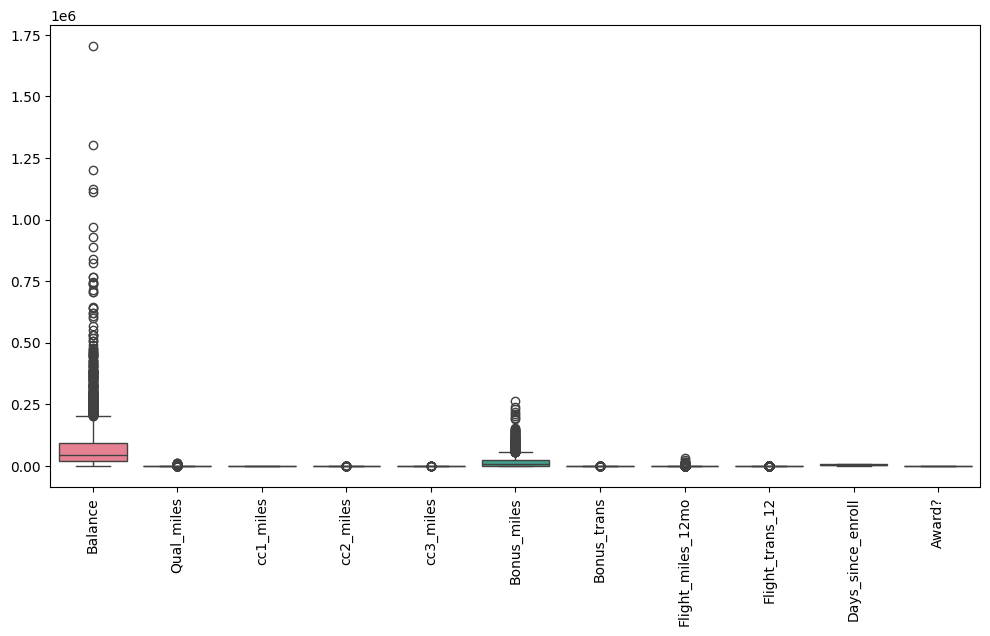

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

### Remove Outliers

In [29]:
import numpy as np

for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

### Feature Scaling

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

### Correlation Heatmap

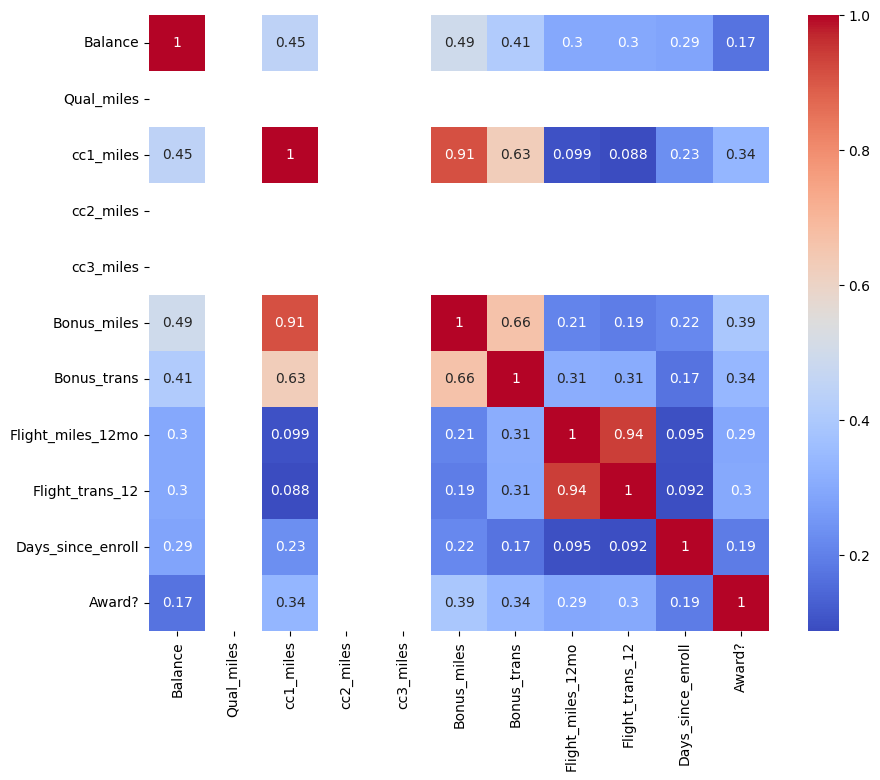

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

### K-Means – Elbow Method

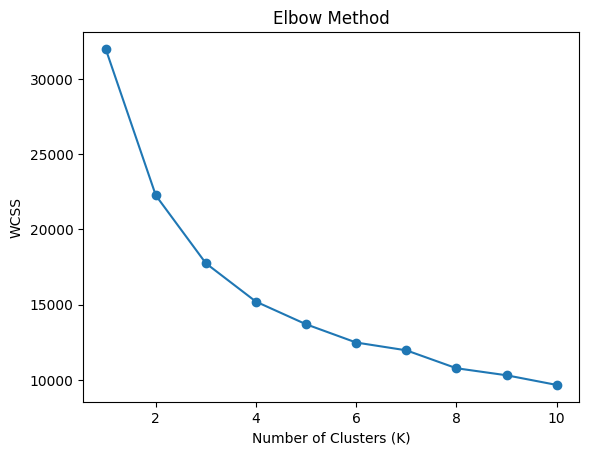

In [32]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

### Apply K-Means

In [33]:
kmeans = KMeans(n_clusters=4, random_state=42)
y_kmeans = kmeans.fit_predict(df_scaled)

df['Cluster_KMeans'] = y_kmeans

### K-Means Visualization

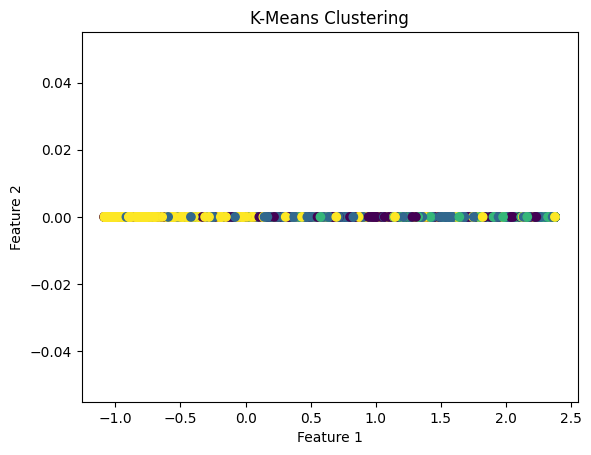

In [34]:
import matplotlib.pyplot as plt

plt.scatter(df_scaled[:,0], df_scaled[:,1], c=y_kmeans)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [35]:
df.groupby('Cluster_KMeans').mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
Cluster_KMeans,,,,,,,,,,,
0,76130.600081,0.0,1.212318,1.0,1.0,7674.886953,10.507293,646.921394,2.092382,4127.752026,0.513776
1,88696.979360,0.0,3.454545,1.0,1.0,30234.419295,16.744898,26.167904,0.114100,4763.798701,0.517625
2,125077.225686,0.0,4.024938,1.0,1.0,44366.632793,24.927681,638.718204,2.018703,5041.586035,0.802993
3,32720.379926,0.0,1.129795,1.0,1.0,3420.064635,5.959538,15.007357,0.074619,3555.567525,0.149238


### Hierarchical Clustering

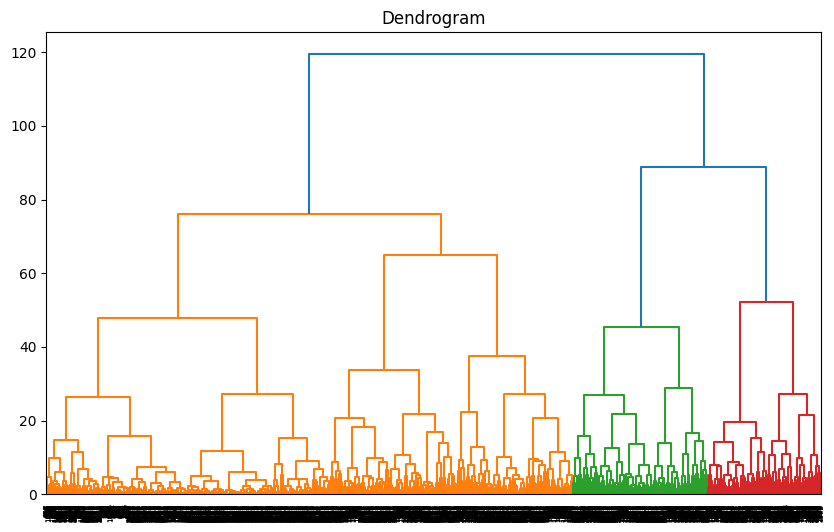

In [36]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(df_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

### Hierarchical Clustering Apply

In [37]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
y_hc = hc.fit_predict(df_scaled)

df['Cluster_Hierarchical'] = y_hc

In [38]:
df.groupby('Cluster_Hierarchical').mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Cluster_KMeans
Cluster_Hierarchical,,,,,,,,,,,,
0,79761.090040,0.0,2.423904,1.0,1.0,17918.174104,12.491633,55.899602,0.212749,4302.567331,0.563347,1.610359
1,102337.149228,0.0,4.246998,1.0,1.0,46829.789880,21.929674,371.967410,1.209262,5057.771870,0.878216,1.468268
2,78522.887374,0.0,1.441894,1.0,1.0,9787.424677,11.642755,609.373745,1.993544,4051.479197,0.375897,0.674319
3,27675.953552,0.0,1.170082,1.0,1.0,3426.640027,6.348361,0.204918,0.002732,3618.739754,0.000000,2.897541


###### Hierarchical clustering grouped customers into distinct segments similar to K-Means, with clear separation between high-value, medium-value, and low-value customers. The dendrogram helped visualize hierarchical relationships among customer groups.

### DBSCAN

In [39]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=1.5, min_samples=5)
y_db = db.fit_predict(df_scaled)

df['Cluster_DBSCAN'] = y_db

### DBSCAN Analysis

In [40]:
df.groupby('Cluster_DBSCAN').mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Cluster_KMeans,Cluster_Hierarchical
Cluster_DBSCAN,,,,,,,,,,,,,
-1,127326.420000,0.0,2.800000,1.0,1.0,40032.030000,31.400000,578.080000,1.920000,3713.440000,0.44,1.520000,1.200000
0,55605.961062,0.0,1.696086,1.0,1.0,9782.437899,8.988419,109.335863,0.366014,3822.806709,0.00,2.202077,2.123003
1,76592.032313,0.0,2.665986,1.0,1.0,24579.242687,15.359864,288.309864,0.953061,4629.234694,1.00,1.385714,0.695918


### Silhouette Score

In [41]:
from sklearn.metrics import silhouette_score

print("KMeans:", silhouette_score(df_scaled, y_kmeans))
print("DBSCAN:", silhouette_score(df_scaled, y_db))

KMeans: 0.307123045013532
DBSCAN: 0.21012299005328042


## CONCLUSION

###### Among all clustering techniques applied, K-Means performed the best with a higher silhouette score, indicating better-defined clusters. Hierarchical clustering provided similar segmentation with useful visualization through dendrograms. DBSCAN, while useful for detecting noise, did not perform well on this dataset due to the lack of clear density-based clusters. Overall, K-Means is the most suitable algorithm for this customer segmentation task.